# X/Y 交流控制噪声谱测量

测量 Bell-Bloom 磁力仪的探测光 $S_1$ 的功率谱密度 $S_{S_1}(\omega, \Omega_\text{Ctrl})$，通过二维拟合同时提取可控噪声谱 $S_\beta(\omega)$ 和不可控噪声 $N_{S_1}(\omega)$，为 Floquet 最优控制提供输入。

## 原理

扫描 X/Y 补偿线圈的交流控制场幅度，在不同控制强度 $\Omega_\text{Ctrl}$ 下，$S_\beta(\omega)$ 受到洛伦兹滤波函数 $L(\omega, \Omega_\text{Ctrl})$ 的不同调制，而 $N_{S_1}(\omega)$ 保持不变。通过二维拟合实现宽带噪声谱重建。

## 硬件连接

| 信号 | 仪器 | 通道 | 说明 |
|------|------|------|------|
| X 控制 | DG4000 (DG4E234902522) | CH1 | 9kHz Burst 正弦波，幅度扫场 |
| Y 控制 | DG4000 (DG4E234902522) | CH2 | 9kHz Burst 正弦波，X+90° |
| Pump 调制 | DG4000 (DG4E222800868) | CH1+CH2 | 100MHz 正弦 + 脉冲门控 (RF 开关) |
| 主磁场 | GS200 | - | 恒流模式，~9.3 mA |
| Pump 光功率 | DG4000 (DG4E231500376) | CH1 DC | - |
| Probe 光功率 | DG4000 (DG4E231500376) | CH2 DC | - |
| 温度控制 | TEC103 | - | 气室温度控制 |
| 温度开关 | DG4000 (DG4E271200104) | CH2 | TTL 电平控制温控通断 |
| 噪声采集+相位校准 | HF2 锁相 | 信号输入 0 | DAQ 模块采集解调信号 |

## 实验参数概览

- **扫描范围**: XY 幅度 0.01 V → 7.0 V, 700 点
- **控制频率**: 9 kHz, X/Y 相位差 90°
- **DAQ 采集**: 时长 1.0 s, 采样率 ~500 kSa/s
- **每点稳定时间**: 0.5 s (关闭温控后的稳定等待)

## 目录

1. [环境准备](#env) — 库导入、参数配置、安全校验、设备连接、初始值设置
2. [相位校准](#phase-cal) — Pump 调制配置，关闭温控与 XYZ 磁场，HF2 解调器自动相位校准
3. [X/Y 控制信号配置与正交校准](#xy-setup) — Burst 模式，相位延迟、外部触发同步、读取 HF2 相位修正 XY_CTRL_QUAD
4. [数据采集](#acq) — 逐点扫描 X/Y 幅度，HF2 DAQ 时域波形采集
5. [数据分析](#analysis) — Welch PSD 计算、幅频标定、洛伦兹拟合与噪声谱参数提取
6. [结果可视化](#plot) — PSD 伪彩图、拟合示例图、可控/不可控噪声谱
7. [安全关闭](#cleanup) — 设备输出关闭、连接断开

<a id='env'></a>
## 1. 环境准备

导入依赖库、加载实验参数与安全限值配置、建立仪器连接、设置初始值（光功率、主磁场、温度）。

In [ ]:
# ========== 交互式绘图模式 ==========
%matplotlib widget

from pathlib import Path
import sys
# 自动定位项目根目录（以 params/ 目录为标记）
project_root = Path.cwd()
while not (project_root / "params").exists() and project_root.parent != project_root:
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import yaml
import time
import json
from datetime import datetime
import matplotlib.pyplot as plt
from tqdm import tqdm

# 设备库
from gs200 import GS200Instrument
from signal_generator import DG4000Instrument
from tec_controller import TECInstrument
from lockin_amplifier import (
    HF2Instrument, DAQConfig, DAQResult,
    SignalInputConfig, OscillatorConfig, DemodulatorConfig,
    demod, daq,
)

# 数据分析库
from scipy import signal as scipy_signal
from scipy.optimize import curve_fit
# ========== 实验参数 ==========
EXPERIMENT_TYPE = "Noise_Spectrum_XY_Ctrl"
PURPOSE = "noise_spectroscopy"

print("所有库导入成功")

所有库导入成功


In [2]:
# 加载物理量→仪器映射
with open(project_root / "params" / "mapping.yaml", encoding="utf-8") as f:
    MAPPING = yaml.safe_load(f)["mapping"]

# 加载安全限值
with open(project_root / "params" / "safety_limits.yaml", encoding="utf-8") as f:
    LIMITS = yaml.safe_load(f)["safety_limits"]

# ========== 实验参数 ==========
EXPERIMENT_TYPE = "Noise_Spectrum_XY_Ctrl"
PURPOSE = "noise_spectroscopy"

# ---- 扫描参数 ----
XY_AMP_START = 0.01        # X/Y 幅度扫描起始 (V)
XY_AMP_STOP = 7.0          # X/Y 幅度扫描终止 (V)
XY_AMP_POINTS = 700        # 扫描点数
XY_SETTLE_TIME = 0.5      # 每点等待稳定时间 (s)

# ---- X/Y 交流控制信号 ----
# Bell-Bloom 原理: 原子以 Larmor 频率绕 B0 进动，XY 控制场须沿原子极化方向施加
#   XY_CTRL_PHASE:  XY 整体相对 Pump 调制信号的相位延迟 (deg)，需实验校准
#   XY_CTRL_QUAD:   X 与 Y 之间的正交相位差 (deg)，初始值 90°，后续由校准修正
#   XY_CALIB_AMP:   正交校准时的 XY 幅值 (V)，使用较大幅值可获得更好的信噪比
XY_CTRL_FREQ = 90e3        # X/Y 交流控制频率 (Hz)，等于 Larmor 频率
XY_CTRL_PHASE = 90         # XY 控制场相对 Pump 调制信号的相位延迟 (deg)
XY_CTRL_QUAD = 90          # X 与 Y 之间的正交相位差 (deg)
XY_CALIB_AMP = 0.5         # XY_CTRL_QUAD 校准时的 XY 幅值 (V)

# ---- Pump 调制参数 ----
PUMP_MOD_FREQ = 90e3       # Pump 调制频率 (Hz)
PUMP_MOD_AMPLITUDE = 0.18  # 100MHz 正弦波幅度 (V)
PUMP_MOD_DUTY = 5          # 脉冲占空比 (%)
RF_GATE_AMPLITUDE = 5.0    # 脉冲门控幅度 (Vpp)
RF_GATE_OFFSET = 2.5       # 脉冲门控偏置 (V)

# ---- HF2 解调配置（相位校准用） ----
HF2_DEMOD_IDX = 0          # 解调器索引
HF2_OSC_FREQ = 90e3        # 振荡器频率 (Hz)，与 Pump 调制频率一致
HF2_SIGNAL_RANGE = 2.0     # 信号输入量程 (V)
HF2_DEMOD_ORDER = 8        # 解调滤波器阶数
HF2_DEMOD_TC = 0.000692    # 解调时间常数 (s) —— 相位校准时使用，较低的带宽确保稳定相位
HF2_DEMOD_RATE = 100000    # 解调输出数据速率 (Sa/s)

# ---- HF2 DAQ 采集配置（噪声采集用） ----
HF2_DAQ_DURATION = 1.0     # DAQ 采集时长 (s)
HF2_DAQ_TC = 7.85e-07      # 解调时间常数 (s) —— 噪声采集时使用，更高的带宽保证频谱平坦
HF2_DAQ_RATE = 100000      # 解调输出数据速率 (Sa/s)，与 DEMOD_RATE 一致
HF2_NPERSEG = 10000        # Welch PSD 每段点数

# ---- 固定参数 ----
FIXED_PARAMS = {
    "Pump_laser_power": 0.1,         "Probe_laser_power": 0.1,
    "temperature": 100,              "Temp_Switch": 5.0,
    "main_magnetic_field": 9.305,
}

# ---- 运行目录命名 ----
RUN_TAG = "noise"

print("配置已加载")

配置已加载


In [3]:
# 安全边界检查函数
def validate_safety_limit(name, value):
    """检查数值是否在安全范围内，超出则报错."""
    lim = LIMITS.get(name)
    if lim is None:
        return value
    lo, hi = lim["min"], lim["max"]
    if lo is not None and hi is not None:
        if value < lo or value > hi:
            raise ValueError(
                f"[安全拦截] {name}={value} 超出范围 [{lo}, {hi}]"
            )
    return value

print("安全校验函数已定义")

安全校验函数已定义


In [4]:
devices = {}

try:
    # ---- GS200: 主磁场 ----
    gs_cfg = MAPPING["main_magnetic_field"]
    gs = GS200Instrument(gs_cfg["resource"])
    gs.connect()
    print(f"GS200 已连接: {gs.idn()}")
    gs.set_source_function(gs_cfg["source_function"])
    # [经验] GS200 需硬件级电流保护
    gs.set_current_limit(LIMITS["main_magnetic_field"]["max"] / 1000.0)
    devices["gs200"] = gs

    # ---- DG4000: X/Y 补偿磁场（Burster） ----
    dg_comp_cfg = MAPPING["X_magnetic_field"]
    dg_comp = DG4000Instrument(dg_comp_cfg["resource"], channel=1)
    dg_comp.connect()
    print(f"补偿场 DG4000 已连接: {dg_comp.idn()}")
    dg_comp.set_ref_clock_source("EXTernal")
    # Y 通道: 通过同一设备 CH2 控制
    devices["dg_comp"] = dg_comp

    # ---- DG4000: Z 磁场扫描（本实验用不到，仅连接并关闭输出）----
    dg_sweep_cfg = MAPPING["Z_magnetic_field"]
    dg_sweep = DG4000Instrument(dg_sweep_cfg["resource"], channel=1)
    dg_sweep.connect()
    print(f"Z 场 DG4000 已连接: {dg_sweep.idn()}")
    dg_sweep.set_ref_clock_source("EXTernal")
    dg_sweep.setup_dc(0.0, channel=1)
    dg_sweep.set_output(False, channel=1)
    dg_sweep.set_output(False, channel=2)
    print(f"  -> Z 场输出: OFF (本实验不使用)")
    devices["dg_sweep"] = dg_sweep

    # ---- DG4000: Pump 调制 ----
    dg_mod_cfg = MAPPING["Pump_modulation"]
    dg_mod = DG4000Instrument(dg_mod_cfg["resource"], channel=1)
    dg_mod.connect()
    print(f"调制 DG4000 已连接: {dg_mod.idn()}")
    devices["dg_mod"] = dg_mod

    # ---- DG4000: 温度开关 ----
    dg_temp_cfg = MAPPING["Temp_Switch"]
    dg_temp = DG4000Instrument(dg_temp_cfg["resource"], channel=2)
    dg_temp.connect()
    print(f"温控 DG4000 已连接: {dg_temp.idn()}")
    devices["dg_temp"] = dg_temp

    # ---- TEC103: 温度控制器 ----
    tec_cfg = MAPPING["temperature"]
    tec = TECInstrument(port=tec_cfg["resource"])
    tec.connect()
    print(f"TEC103 已连接")
    devices["tec"] = tec

    # ---- DG4000: Pump/Probe 光功率 ----
    dg_laser_cfg = MAPPING["Pump_laser_power"]
    dg_laser = DG4000Instrument(dg_laser_cfg["resource"], channel=1)
    dg_laser.connect()
    print(f"光功率 DG4000 已连接: {dg_laser.idn()}")
    devices["dg_laser"] = dg_laser

    # ---- HF2: 锁相放大器 ----
    hf2_cfg = MAPPING["lockin_r"]
    hfi = HF2Instrument(
        host=hf2_cfg.get("host", "127.0.0.1"),
        port=hf2_cfg.get("port", 8005),
        api_level=1,
        device_id=hf2_cfg["device_id"],
    )
    hfi.connect()
    print(f"HF2 已连接: {hfi.idn}")
    hfi.set_extclk(True)
    print(f"  -> HF2 时钟源: 外部")
    devices["hf2"] = hfi

except Exception as e:
    print(f"设备连接失败: {e}")
    raise

print(f"\n所有设备连接完成，共 {len(devices)} 个设备")

GS200 已连接: YOKOGAWA,GS210,90Z631552,2.02
补偿场 DG4000 已连接: Rigol Technologies,DG4162,DG4E234902522,00.01.14
Z 场 DG4000 已连接: Rigol Technologies,DG4162,DG4E242401288,00.01.14
  -> Z 场输出: OFF (本实验不使用)
调制 DG4000 已连接: Rigol Technologies,DG4162,DG4E222800868,00.01.14
温控 DG4000 已连接: RIGOL TECHNOLOGIES,DG912 Pro,DG9Q271200104,00.02.00.00.05
TEC103 已连接
光功率 DG4000 已连接: Rigol Technologies,DG4162,DG4E231500376,00.01.14
HF2 已连接: HF2LI
  -> HF2 时钟源: 外部

所有设备连接完成，共 8 个设备


In [5]:
hfi = devices["hf2"]
tec = devices["tec"]
gs = devices["gs200"]
dg_laser = devices["dg_laser"]
dg_comp = devices["dg_comp"]
dg_sweep = devices["dg_sweep"]
dg_mod = devices["dg_mod"]
dg_temp = devices["dg_temp"]

# ---- 1. Pump 光功率 ----
validate_safety_limit("Pump_laser_power", FIXED_PARAMS["Pump_laser_power"])
dg_laser.setup_dc(FIXED_PARAMS["Pump_laser_power"], channel=1)
print(f"Pump 光功率: {FIXED_PARAMS['Pump_laser_power']} V DC")

# ---- 2. Probe 光功率 ----
validate_safety_limit("Probe_laser_power", FIXED_PARAMS["Probe_laser_power"])
dg_laser.setup_dc(FIXED_PARAMS["Probe_laser_power"], channel=2)
print(f"Probe 光功率: {FIXED_PARAMS['Probe_laser_power']} V DC")

# ---- 3. 主磁场 ----
validate_safety_limit("main_magnetic_field", FIXED_PARAMS["main_magnetic_field"])
gs.set_current(FIXED_PARAMS["main_magnetic_field"] / 1000.0)
gs.set_output(True)
print(f"主磁场: {FIXED_PARAMS['main_magnetic_field']} mA")

# ---- 4. 温度开关 (ON) ----
validate_safety_limit("Temp_Switch", FIXED_PARAMS["Temp_Switch"])
dg_temp.setup_dc(FIXED_PARAMS["Temp_Switch"], channel=2)
dg_temp.set_output(True, channel=2)
print(f"温度开关: ON ({FIXED_PARAMS['Temp_Switch']} V)")

# ---- 5. 温度控制 ----
validate_safety_limit("temperature", FIXED_PARAMS["temperature"])
tec.set_target_temperature(FIXED_PARAMS["temperature"], channel=1)
tec.set_enable(True, channel=1)
temp_now = tec.get_temperature(channel=1)
print(f"温度设定: {FIXED_PARAMS['temperature']} °C, 当前: {temp_now:.1f} °C")
print("等待温度稳定...")
while True:
    time.sleep(5)
    t = tec.get_temperature(channel=1)
    print(f"  当前温度: {t:.2f} °C")
    try:
        t2 = tec.get_temperature(channel=1)
        if abs(t2 - FIXED_PARAMS['temperature']) < 1:
            print(f"温度已稳定: {t:.2f} °C")
            break
    except:
        pass

# ---- 6. Z 磁场输出确认关闭 ----
validate_safety_limit("Z_magnetic_field", 0.0)
dg_sweep.setup_dc(0.0, channel=1)
dg_sweep.set_output(False, channel=1)
dg_sweep.set_output(False, channel=2)
print("Z 磁场: DC 0V, 输出 OFF (本实验不使用)")

# ---- 创建运行目录 ----
timestamp = datetime.now().strftime("%m%d_%H%M")
run_dir = project_root / "data" / EXPERIMENT_TYPE / f"{timestamp}_{RUN_TAG}"
run_dir.mkdir(parents=True, exist_ok=True)
(raw_dir := run_dir / "raw").mkdir(exist_ok=True)
(results_dir := run_dir / "results").mkdir(exist_ok=True)
print(f"运行目录: {run_dir}")

# ---- 保存实验配置到运行目录 ----
config = {
    "experiment_type": EXPERIMENT_TYPE,
    "purpose": PURPOSE,
    "timestamp": timestamp,
    "scan_params": {
        "XY_AMP_START_V": XY_AMP_START,
        "XY_AMP_STOP_V": XY_AMP_STOP,
        "XY_AMP_POINTS": XY_AMP_POINTS,
        "XY_SETTLE_TIME_s": XY_SETTLE_TIME,
    },
    "xy_ctrl": {
        "XY_CTRL_FREQ_Hz": XY_CTRL_FREQ,
        "XY_CTRL_PHASE_deg": XY_CTRL_PHASE,
        "XY_CTRL_QUAD_deg": XY_CTRL_QUAD,
        "XY_CALIB_AMP_V": XY_CALIB_AMP,
    },
    "fixed_params": FIXED_PARAMS,
    "pump_modulation": {
        "pump_mod_freq_Hz": PUMP_MOD_FREQ,
        "pump_mod_amplitude_V": PUMP_MOD_AMPLITUDE,
        "pump_mod_duty_pct": PUMP_MOD_DUTY,
    },
    "hf2_demod": {
        "demod_idx": HF2_DEMOD_IDX,
        "osc_freq_Hz": HF2_OSC_FREQ,
        "signal_range_V": HF2_SIGNAL_RANGE,
        "demod_rate_Sa_s": HF2_DEMOD_RATE,
        "demod_TC_s": HF2_DEMOD_TC,
    },
    "hf2_daq": {
        "DAQ_duration_s": HF2_DAQ_DURATION,
        "DAQ_TC_s": HF2_DAQ_TC,
        "DAQ_rate_Sa_s": HF2_DAQ_RATE,
        "nperseg": HF2_NPERSEG,
    },
}
config_path = run_dir / "experiment_config.yaml"
with open(config_path, "w", encoding="utf-8") as f:
    yaml.dump(config, f, default_flow_style=False, allow_unicode=True)
print(f"实验配置已保存: {config_path}")

print("\n初始值设置完成")

Pump 光功率: 0.1 V DC
Probe 光功率: 0.1 V DC
主磁场: 9.305 mA
温度开关: ON (5.0 V)
温度设定: 100 °C, 当前: 100.0 °C
等待温度稳定...
  当前温度: 100.00 °C
温度已稳定: 100.00 °C
Z 磁场: DC 0V, 输出 OFF (本实验不使用)
运行目录: d:\Code\exp_agent\data\Noise_Spectrum_XY_Ctrl\0520_1510_noise
实验配置已保存: d:\Code\exp_agent\data\Noise_Spectrum_XY_Ctrl\0520_1510_noise\experiment_config.yaml

初始值设置完成


<a id='phase-cal'></a>
## 2. 相位校准

配置 Pump 调制 RF 开关方案，在 XYZ 磁场关闭状态下对 HF2 解调器进行自动相位校准。

In [10]:
# ---- 配置 RF 开关方案（Pump 调制） ----
print("CH1: 配置 100MHz 连续正弦波...")
dg_mod.setup_sine(freq=100e6, amplitude=PUMP_MOD_AMPLITUDE,
                  offset=0.0, phase=0.0, channel=1)
print(f"  100MHz, 幅度 {PUMP_MOD_AMPLITUDE*1000:.0f} mVpp → RF 开关 IN")

pulse_width = (PUMP_MOD_DUTY / 100.0) / PUMP_MOD_FREQ
print(f"\nCH2: 配置 {PUMP_MOD_FREQ/1e3:.0f} kHz 脉冲门控...")
print(f"  脉宽: {pulse_width*1e6:.2f} μs ({PUMP_MOD_DUTY}% duty)")
dg_mod.setup_pulse(freq=PUMP_MOD_FREQ, amplitude=RF_GATE_AMPLITUDE,
                   offset=RF_GATE_OFFSET, width=pulse_width, channel=2)
print(f"  {PUMP_MOD_FREQ/1e3:.0f} kHz → RF 开关 CTRL")

# 启用 Pump 调制输出及 SYNC 信号
# dg_mod CH2 SYNC → dg_comp Ext Trig（用作 XY Burst 外部触发同步）
dg_mod.set_output(True, channel=1)
dg_mod.set_output(True, channel=2)
dg_mod.set_sync_state(True, channel=2)
print("  dg_mod 输出: CH1(100MHz) ON, CH2(脉冲) ON")
print("  dg_mod CH2 SYNC → dg_comp Ext Trig")

print("\n✅ RF 开关方案配置完成")

# ---- HF2 解调器相位校准（设置 XY 磁场前执行） ----
# 参考: Static_Magnetic_Field_Sensitivity.ipynb 相位校准流程
# 校准时 XYZ 磁场均处于关闭状态，仅主磁场 B0 保持稳定
print("\n关闭温度开关（相位校准前，消除温控磁场干扰）...")
dg_temp.set_output(False, channel=2)

# 确认 X/Y 补偿磁场处于关闭状态（尚未配置）
print("确认 X/Y 补偿磁场关闭...")
dg_comp.set_output(False, channel=1)
dg_comp.set_output(False, channel=2)

# 配置信号输入
sig_in_cfg = SignalInputConfig(
    input_index=0, range=HF2_SIGNAL_RANGE,
    ac_coupling=True, diff=False, impedance=50,
)
demod.configure_signal_input(hfi, sig_in_cfg)
print(f"信号输入已配置: {HF2_SIGNAL_RANGE} V range, AC coupled")

# 配置振荡器
osc_cfg = OscillatorConfig(
    osc_index=0, frequency=HF2_OSC_FREQ, source="manual",
)
demod.configure_oscillator(hfi, osc_cfg)
print(f"振荡器已配置: {HF2_OSC_FREQ/1e3:.0f} kHz")

# 配置解调器
demod_cfg = DemodulatorConfig(
    demod_index=0, enable=True, rate=HF2_DEMOD_RATE,
    input_channel=0, osc_select=0, harmonic=1,
    time_constant=HF2_DEMOD_TC, order=HF2_DEMOD_ORDER, phase=0.0,
)
actual_rate = demod.configure_demodulator(hfi, demod_cfg)
print(f"解调器 0 已配置: rate={actual_rate:.0f} Sa/s, TC={HF2_DEMOD_TC*1000:.3f} ms")

# 自动相位校准
print("正在进行相位校准...")
calibrated_phase = demod.auto_calibrate_phase(
    hfi, demod_idx=0, tolerance_deg=1.0, max_attempts=5, settle_time=0.2
)
print(f"相位校准完成: {calibrated_phase:.2f}°")

# 读一组样本验证
sample = demod.read_demod_sample(hfi, demod_idx=0)
print(f"校准后样本: R={sample['r']:.6f}, X={sample['x']:.6f}, Y={sample['y']:.6f}")

time.sleep(0.5)

# 恢复温控
print("恢复温度开关...")
dg_temp.set_output(True, channel=2)
time.sleep(0.5)

CH1: 配置 100MHz 连续正弦波...
  100MHz, 幅度 180 mVpp → RF 开关 IN

CH2: 配置 90 kHz 脉冲门控...
  脉宽: 0.56 μs (5% duty)
  90 kHz → RF 开关 CTRL
  dg_mod 输出: CH1(100MHz) ON, CH2(脉冲) ON
  dg_mod CH2 SYNC → dg_comp Ext Trig

✅ RF 开关方案配置完成

关闭温度开关（相位校准前，消除温控磁场干扰）...
确认 X/Y 补偿磁场关闭...
信号输入已配置: 2.0 V range, AC coupled
振荡器已配置: 90 kHz
解调器 0 已配置: rate=115132 Sa/s, TC=0.692 ms
正在进行相位校准...
相位校准完成: 41.72°
校准后样本: R=0.266510, X=0.266501, Y=-0.002136
恢复温度开关...


<a id='xy-setup'></a>
## 3. X/Y 控制信号配置与正交校准

配置 Burst 模式 X/Y 控制信号（相位延迟 + 外部触发同步），读取 HF2 相位偏移校准 XY_CTRL_QUAD 正交相位差。

In [11]:
# ---- X/Y 控制信号配置（Burst 模式，外部触发同步）----
# Bell-Bloom 磁力仪物理原理:
#   原子以 Larmor 频率绕主磁场 B0 进动，Pump 光脉冲与之同步。
#   X/Y 控制磁场必须沿原子极化方向施加，因此:
#     1. X 和 Y 相差 90° 相位（正交控制，沿极化方向旋转）
#     2. XY 整体需相位延迟 XY_CTRL_PHASE 与 Pump 调制对齐
# 同步机制:
#   dg_mod CH2 SYNC → dg_comp Ext Trig（需硬件连接）
#   XY Burst 由 Pump 触发启动，确保固定相位关系
# 注: 初始幅值使用 XY_CALIB_AMP（校准幅值），
#     后续扫描循环从 XY_AMP_START 开始
print("配置 X/Y 交流控制信号（Burst 模式，外部触发同步）...")
XY_CALIB_AMP = 3
# ---- CH1: X 通道 ----
# 相位 = XY_CTRL_PHASE（相对 Pump 调制的整体延迟）
dg_comp.setup_sine(freq=XY_CTRL_FREQ, amplitude=XY_CALIB_AMP,
                   offset=0.0, phase=0, channel=1)
dg_comp.set_burst_state(True, channel=1)
dg_comp.set_burst_mode("INFinity", channel=1)
dg_comp.set_burst_ncycles(50000, channel=1)
dg_comp.set_burst_phase(XY_CTRL_PHASE % 360, channel=1)
dg_comp.set_burst_trigger_source("EXTernal", channel=1)
print(f"  X CH1: Burst 模式, {XY_CTRL_FREQ} Hz, 幅度 {XY_CALIB_AMP} V, "
      f"相位 {XY_CTRL_PHASE % 360}° (相对 Pump)")

# ---- CH2: Y 通道 ----
# 相位 = X + XY_CTRL_QUAD = X + 90°（正交控制）
dg_comp.setup_sine(freq=XY_CTRL_FREQ, amplitude=XY_CALIB_AMP,
                   offset=0.0, phase=0, channel=2)
dg_comp.set_burst_state(True, channel=2)
dg_comp.set_burst_mode("INFinity", channel=2)
dg_comp.set_burst_ncycles(50000, channel=2)
dg_comp.set_burst_phase((XY_CTRL_PHASE + XY_CTRL_QUAD) % 360, channel=2)
dg_comp.set_burst_trigger_source("EXTernal", channel=2)
print(f"  Y CH2: Burst 模式, {XY_CTRL_FREQ} Hz, 幅度 {XY_CALIB_AMP} V, "
      f"相位 {(XY_CTRL_PHASE + XY_CTRL_QUAD) % 360}° (= X + {XY_CTRL_QUAD}°)")

# 打开输出（等待 Pump 调制 SYNC 外部触发启动 Burst）
dg_comp.set_output(False, channel=1)
dg_comp.set_output(False, channel=2)
print("  X/Y 输出 OFF (等待外部触发启动 Burst)")
print()
print("硬件同步要求: dg_mod CH2 SYNC → dg_comp Ext Trig 需物理连接")
print(f"相位关系: X={XY_CTRL_PHASE}°, Y=X+{XY_CTRL_QUAD}°={XY_CTRL_PHASE + XY_CTRL_QUAD}°")
print(f"幅值: {XY_CALIB_AMP} V（校准用，扫描起始 {XY_AMP_START} V）")

配置 X/Y 交流控制信号（Burst 模式，外部触发同步）...
  X CH1: Burst 模式, 90000.0 Hz, 幅度 3 V, 相位 90° (相对 Pump)
  Y CH2: Burst 模式, 90000.0 Hz, 幅度 3 V, 相位 180° (= X + 90°)
  X/Y 输出 OFF (等待外部触发启动 Burst)

硬件同步要求: dg_mod CH2 SYNC → dg_comp Ext Trig 需物理连接
相位关系: X=90°, Y=X+90°=180°
幅值: 3 V（校准用，扫描起始 0.01 V）


In [12]:
# ---- XY_CTRL_QUAD 校准：读取锁相相位修正正交相位差 ----
# 原理:
#   HF2 自动相位校准后 Y ≈ 0（信号全部在 X 通道）。
#   XY 控制场开启后改变了原子极化的旋转相位，锁相读数产生偏移。
#   该相位偏移量即为 XY_CTRL_QUAD 所需修正值。
# 步骤:
#   迭代校准: 每次读取 HF2 相位偏移修正 XY_CTRL_PHASE，
#   直到修正量绝对值 < 1° 时收敛退出。
MAX_CALIB_ITER = 10  # 最大迭代次数，防止死循环

print("=" * 50)
print("校准 XY_CTRL_PHASE（迭代收敛）")
print("=" * 50)

for calib_iter in range(1, MAX_CALIB_ITER + 1):
    print(f"\n--- 第 {calib_iter} 次校准迭代 ---")

    # 1. 打开磁场关闭温控
    dg_comp.set_output(True, channel=1)
    dg_comp.set_output(True, channel=2)

    dg_temp.set_output(False, channel=2)
    time.sleep(1)

    # 2. 读取 HF2 解调器 X/Y 相位
    sample = demod.read_demod_sample(hfi, demod_idx=0)
    phase_deg = float(np.degrees(np.arctan2(sample['y'], sample['x'])))
    print(f"  相位偏移: {phase_deg:+.2f}°")

    # 恢复温控，等待下次迭代
    dg_temp.set_output(True, channel=2)
    time.sleep(2)

    # 检查收敛条件：修正量绝对值 < 1° 时校准完成
    if abs(phase_deg) < 1.0:
        print(f"  ✓ 收敛 (|{phase_deg:.2f}°| < 1°)")
        dg_temp.set_output(True, channel=2)
        time.sleep(1)
        break

    # 3. 修正 XY_CTRL_PHASE（保持在 [0, 360) 范围，兼容 DG4000 相位要求）
    old_phase = XY_CTRL_PHASE
    XY_CTRL_PHASE = (XY_CTRL_PHASE - phase_deg) % 360
    print(f"  修正: {old_phase:.2f}° → {XY_CTRL_PHASE:.2f}°")

    # 4. 更新 XY Burst 相位（CH1 和 CH2 均取模 360）
    dg_comp.set_burst_state(False, channel=1)
    dg_comp.set_burst_state(False, channel=2)

    dg_comp.set_output(False, channel=1)
    dg_comp.set_output(False, channel=2)

    dg_comp.set_burst_state(True, channel=1)
    dg_comp.set_burst_state(True, channel=2)

    dg_comp.set_burst_phase(XY_CTRL_PHASE % 360, channel=1)
    dg_comp.set_burst_phase((XY_CTRL_PHASE + XY_CTRL_QUAD) % 360, channel=2)

    dg_comp.set_output(True, channel=1)
    dg_comp.set_output(True, channel=2)

else:
    print(f"\n⚠️ 达到最大迭代次数 {MAX_CALIB_ITER}，校准可能未完全收敛")

print(f"\n✅ XY_CTRL_PHASE = {XY_CTRL_PHASE:.2f}° 校准完成")

校准 XY_CTRL_PHASE（迭代收敛）

--- 第 1 次校准迭代 ---
  相位偏移: -26.20°
  修正: 90.00° → 116.20°

--- 第 2 次校准迭代 ---
  相位偏移: -0.59°
  ✓ 收敛 (|-0.59°| < 1°)

✅ XY_CTRL_PHASE = 116.20° 校准完成


In [14]:
amp = 2
dg_comp.set_amplitude(amp, channel=1)
dg_comp.set_amplitude(amp, channel=2)

# 强制重新触发以对齐相位
dg_comp.set_output(False, channel=1)
dg_comp.set_output(False, channel=2)
time.sleep(0.01)
dg_comp.set_output(True, channel=1)
dg_comp.set_output(True, channel=2)
time.sleep(0.3)

# 读 HF2 相位检查是否稳定
sample = demod.read_demod_sample(hfi, demod_idx=0)
phase_deg = float(np.degrees(np.arctan2(sample['y'], sample['x'])))
print(f"幅度={amp}V, 相位偏移={phase_deg:+.2f}°")


幅度=2V, 相位偏移=-0.78°


<a id='acq'></a>
## 4. 数据采集

逐点扫描 X/Y 控制幅度，每点经稳定时间后由 HF2 DAQ 模块采集解调时域信号。

In [15]:
# ===== 逐点扫描 X/Y 幅度 + HF2 DAQ 采集 =====

amplitudes = np.linspace(XY_AMP_START, XY_AMP_STOP, XY_AMP_POINTS)
print("=" * 60)
print(f"X/Y 幅度扫描噪声谱测量")
print("=" * 60)
print(f"控制频率: {XY_CTRL_FREQ} Hz")
print(f"扫描范围: {XY_AMP_START} V → {XY_AMP_STOP} V, {XY_AMP_POINTS} 点")
print(f"DAQ 采集: 时长 {HF2_DAQ_DURATION}s, TC={HF2_DAQ_TC*1e6:.2f}μs, rate={HF2_DAQ_RATE:.0f} Sa/s")
total_est = XY_AMP_POINTS * (XY_SETTLE_TIME + HF2_DAQ_DURATION + 2.0)
print(f"预计耗时: {total_est:.0f}s ≈ {total_est/3600:.1f}h")
print()

grid_cols = int(actual_rate * HF2_DAQ_DURATION)

# 切换到噪声采集用解调器参数（更短 TC，更高带宽）
print(f"切换到 DAQ 采集解调器参数: TC={HF2_DAQ_TC*1e6:.2f} μs, Rate={HF2_DAQ_RATE} Sa/s")
daq_demod_cfg = DemodulatorConfig(
    demod_index=0, enable=True,
    rate=HF2_DAQ_RATE, input_channel=0,
    osc_select=0, harmonic=1,
    time_constant=HF2_DAQ_TC, order=HF2_DEMOD_ORDER,
    phase=calibrated_phase,
)
actual_rate_daq = demod.configure_demodulator(hfi, daq_demod_cfg)
grid_cols = int(actual_rate_daq * HF2_DAQ_DURATION)
time.sleep(0.2)

t_start = time.time()

# try/finally 确保异常时恢复温度开关
pbar = tqdm(total=XY_AMP_POINTS, desc="Scanning", unit="pt")
try:
    for i, amp in enumerate(amplitudes):
        pbar.set_postfix_str(f"A={amp:.3f}V")

        # 修改幅度后重新触发 Burst 以对齐相位
        dg_comp.set_amplitude(amp, channel=1)
        dg_comp.set_amplitude(amp, channel=2)
        dg_comp.set_output(False, channel=1)
        dg_comp.set_output(False, channel=2)
        time.sleep(0.1)
        dg_comp.set_output(True, channel=1)
        dg_comp.set_output(True, channel=2)
        time.sleep(0.3)

        # 关闭温度开关（消除温控磁场干扰）
        dg_temp.set_output(False, channel=2)

        # 等待系统稳定
        time.sleep(XY_SETTLE_TIME)

        # 读取当前温度
        try:
            temp_now = tec.get_temperature(channel=1)
            pbar.set_postfix_str(f"A={amp:.3f}V, T={temp_now:.1f}°C")
        except:
            pbar.set_postfix_str(f"A={amp:.3f}V")

        # 配置 HF2 DAQ 采集（每点独立配置）
        daq_cfg = DAQConfig(
            device=MAPPING["lockin_r"]["device_id"],
            trigger_type=0,                  # 连续模式
            duration=HF2_DAQ_DURATION,
            grid_cols=grid_cols,
            grid_rows=1,
            grid_mode=2,
            signal_paths=["sample.y"],       # 采集幅值信号
        )

        # 采集解调时域信号
        try:
            results = daq.acquire_data(
                hfi, daq_cfg, demod_idx=0,
                actual_rate=actual_rate_daq, timeout=HF2_DAQ_DURATION + 10.0,
            )
            waveform = results[0].values
        except Exception as e:
            tqdm.write(f"  [{i:4d}/{XY_AMP_POINTS}] amp={amp:.4f}V: DAQ 采集失败: {e}")
            waveform = np.array([np.nan])

        # 保存原始波形（.npy 二进制格式）
        np.save(raw_dir / f"waveform_C{i:04d}.npy", waveform)

        # 恢复温度开关
        dg_temp.set_output(True, channel=2)
        time.sleep(2)

        pbar.update(1)

except Exception as e:
    print(f"\n❌ 扫描出错: {e}")
    # 紧急恢复温度开关
    print("紧急恢复温度开关...")
    dg_temp.set_output(True, channel=2)
    raise

finally:
    pbar.close()
    # [经验] 确保异常退出时温控恢复
    dg_temp.set_output(True, channel=2)
    print("温度开关已恢复 ON")

elapsed_total = time.time() - t_start
print(f"\n✅ 扫描完成！共 {XY_AMP_POINTS} 点, 用时 {elapsed_total:.0f}s")
print(f"原始波形保存在: {raw_dir}")

# 恢复解调器至相位校准参数
print("恢复解调器 TC...")
restore_demod_cfg = DemodulatorConfig(
    demod_index=0, enable=True,
    rate=HF2_DEMOD_RATE, input_channel=0,
    osc_select=0, harmonic=1,
    time_constant=HF2_DEMOD_TC, order=HF2_DEMOD_ORDER,
    phase=calibrated_phase,
)  
demod.configure_demodulator(hfi, restore_demod_cfg)
time.sleep(0.2)
print(f"解调器已恢复: TC={HF2_DEMOD_TC*1e6:.0f} μs, Rate={HF2_DEMOD_RATE} Sa/s")

X/Y 幅度扫描噪声谱测量
控制频率: 90000.0 Hz
扫描范围: 0.01 V → 7.0 V, 700 点
DAQ 采集: 时长 1.0s, TC=0.79μs, rate=100000 Sa/s
预计耗时: 2450s ≈ 0.7h

切换到 DAQ 采集解调器参数: TC=0.79 μs, Rate=100000 Sa/s


Scanning: 100%|██████████| 700/700 [1:05:15<00:00,  5.59s/pt, A=7.000V, T=90.3°C]


温度开关已恢复 ON

✅ 扫描完成！共 700 点, 用时 3916s
原始波形保存在: d:\Code\exp_agent\data\Noise_Spectrum_XY_Ctrl\0520_0937_noise\raw
恢复解调器 TC...
解调器已恢复: TC=692 μs, Rate=100000 Sa/s


<a id='analysis'></a>
## 5. 数据分析

计算 Welch PSD 矩阵、幅频标定（控制电压 → 有效 Rabi 频率）、洛伦兹拟合提取可控噪声谱和不可控噪声谱。

In [16]:
# ===== 离线数据分析：从保存的配置加载参数 =====
# 重要：后续分析 Cell 将使用本 Cell 从 experiment_config.yaml 加载的参数，
#       而不是笔记本顶部（Cell 5）的默认值。
# 步骤：
#   1. 运行 Cells 1-5（导入库 + 基础配置）
#   2. 运行本 Cell 加载保存的参数
#   3. 依次运行后续分析 Cell
# ⚠️ 不要在本 Cell 之后重新运行 Cell 5（否则会覆盖保存的参数）
# ------------------------------------------------

import yaml

data_root = project_root / "data" / EXPERIMENT_TYPE

# ========== 选择要分析的数据运行 ==========
DATA_RUN = "0520_0937_noise"  # ← 修改这里选择不同数据
# =========================================

run_dir = data_root / DATA_RUN
if not run_dir.exists():
    raise FileNotFoundError(f"运行目录不存在: {run_dir}")

raw_dir = run_dir / "raw"
results_dir = run_dir / "results"

# ---- 从 experiment_config.yaml 加载保存的实验参数 ----
config_path = run_dir / "experiment_config.yaml"
if not config_path.exists():
    raise FileNotFoundError(f"实验配置文件不存在: {config_path}")

with open(config_path, encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

# ===== 覆盖所有分析相关参数 =====
# 来源：保存的 experiment_config.yaml（采集时的实际参数）
print(f"\n{'='*55}")
print(f"从 experiment_config.yaml 加载实验参数:")
print(f"{'='*55}")

# 扫描参数
XY_AMP_START   = cfg["scan_params"]["XY_AMP_START_V"]
XY_AMP_STOP    = cfg["scan_params"]["XY_AMP_STOP_V"]
XY_AMP_POINTS  = cfg["scan_params"]["XY_AMP_POINTS"]
XY_SETTLE_TIME = cfg["scan_params"]["XY_SETTLE_TIME_s"]
print(f"  XY_AMP_START  = {XY_AMP_START} V")
print(f"  XY_AMP_STOP   = {XY_AMP_STOP} V")
print(f"  XY_AMP_POINTS = {XY_AMP_POINTS}")

# DAQ 采集参数（Welch PSD 计算用）
actual_rate_daq = cfg["hf2_daq"]["DAQ_rate_Sa_s"]
HF2_NPERSEG     = cfg["hf2_daq"]["nperseg"]
HF2_DAQ_TC      = cfg["hf2_daq"]["DAQ_TC_s"]
HF2_DAQ_DURATION = cfg["hf2_daq"]["DAQ_duration_s"]
HF2_DAQ_RATE    = cfg["hf2_daq"]["DAQ_rate_Sa_s"]
print(f"  采样率        = {actual_rate_daq} Sa/s")
print(f"  HF2_NPERSEG   = {HF2_NPERSEG}")
print(f"  HF2_DAQ_DURATION = {HF2_DAQ_DURATION} s")
print(f"  HF2_DAQ_TC    = {HF2_DAQ_TC*1e6:.2f} μs")

# ---- 可选：如果之前已保存 PSD 矩阵，可直接加载 ----
LOAD_EXISTING_PSD = True  # True=跳过 Welch 重算，False=从原始波形重新计算
psd_matrix_path = results_dir / "psd_matrix.npz"
calib_path = results_dir / "calibration.npz"

if LOAD_EXISTING_PSD and psd_matrix_path.exists():
    _d = np.load(psd_matrix_path)
    psd_matrix = _d["psd_matrix"]
    freq_axis = _d["freq_axis"]
    amplitudes_used = _d["amplitudes"]
    print(f"\n已加载已有 PSD 矩阵: shape={psd_matrix.shape}")
    if calib_path.exists():
        _c = np.load(calib_path)
        k, b = _c["k"], _c["b"]
        omega_ctrl = _c["omega_ctrl"]
        print(f"已加载已有标定结果: k={k:.2f}, b={b:.2f}")
else:
    # ---- 从原始波形重新计算 PSD ----
    print(f"\n从原始波形重新计算 PSD...")
    n_files = len(list(raw_dir.glob("waveform_C*.npy")))
    print(f"找到 {n_files} 个波形文件")

    psd_list = []
    freq_axis = None

    for i in range(n_files):
        wf_path = raw_dir / f"waveform_C{i:04d}.npy"
        if not wf_path.exists():
            print(f"  ⚠️ 缺失: {wf_path.name}")
            continue

        waveform = np.load(wf_path)

        if np.all(np.isnan(waveform)) or len(waveform) < HF2_NPERSEG:
            print(f"  ⚠️ 无效波形: {wf_path.name}, 跳过 PSD 计算")
            psd_list.append(np.full(HF2_NPERSEG // 2 + 1, np.nan))
            if i == 0:
                freq_axis = np.fft.rfftfreq(HF2_NPERSEG, d=1.0/actual_rate_daq)
            continue

        f, psd = scipy_signal.welch(
            waveform, fs=actual_rate_daq,
            nperseg=min(HF2_NPERSEG, len(waveform)),
            noverlap=None,
            scaling="density",
        )
        if i == 0:
            freq_axis = f
        psd_list.append(psd)

    psd_matrix = np.array(psd_list)
    amplitudes_used = np.linspace(XY_AMP_START, XY_AMP_STOP, len(psd_matrix))

    print(f"PSD 矩阵形状: {psd_matrix.shape}")
    print(f"频率范围: {freq_axis[0]:.0f} - {freq_axis[-1]:.0f} Hz")
    print(f"频率点数: {len(freq_axis)}")

    results_dir.mkdir(parents=True, exist_ok=True)
    np.savez(
        results_dir / "psd_matrix.npz",
        psd_matrix=psd_matrix,
        freq_axis=freq_axis,
        amplitudes=amplitudes_used,
        actual_rate=actual_rate_daq,
    )
    print(f"\nPSD 矩阵已保存: {results_dir / 'psd_matrix.npz'}")

print(f"\n✅ 参数已从 {DATA_RUN}/experiment_config.yaml 加载完成")
print(f"   后续分析 Cell 将使用以上保存的参数进行运算")
print(f"   运行目录: {run_dir}")


从 experiment_config.yaml 加载实验参数:
  XY_AMP_START  = 0.01 V
  XY_AMP_STOP   = 7.0 V
  XY_AMP_POINTS = 700
  采样率        = 100000 Sa/s
  HF2_NPERSEG   = 10000
  HF2_DAQ_DURATION = 1.0 s
  HF2_DAQ_TC    = 0.79 μs

从原始波形重新计算 PSD...
找到 700 个波形文件
PSD 矩阵形状: (700, 5001)
频率范围: 0 - 50000 Hz
频率点数: 5001

PSD 矩阵已保存: d:\Code\exp_agent\data\Noise_Spectrum_XY_Ctrl\0520_0937_noise\results\psd_matrix.npz

✅ 参数已从 0520_0937_noise/experiment_config.yaml 加载完成
   后续分析 Cell 将使用以上保存的参数进行运算
   运行目录: d:\Code\exp_agent\data\Noise_Spectrum_XY_Ctrl\0520_0937_noise


搜索范围: f ∈ [0, 54000] Hz, 5001 频率列
逐列寻峰: 4073/5001 有效峰 (81.4%)
  迭代2σ离群拒绝完成: 保留 2920 点

幅频标定结果:
  k = 6346.99 Hz/V
  b = -263.72 Hz
  Ω_Ctrl = 6346.99 · V + -263.72
标定结果已保存: d:\Code\exp_agent\data\Noise_Spectrum_XY_Ctrl\0520_0937_noise\results\calibration.npz
标定图已保存: d:\Code\exp_agent\data\Noise_Spectrum_XY_Ctrl\0520_0937_noise\results\calibration.png


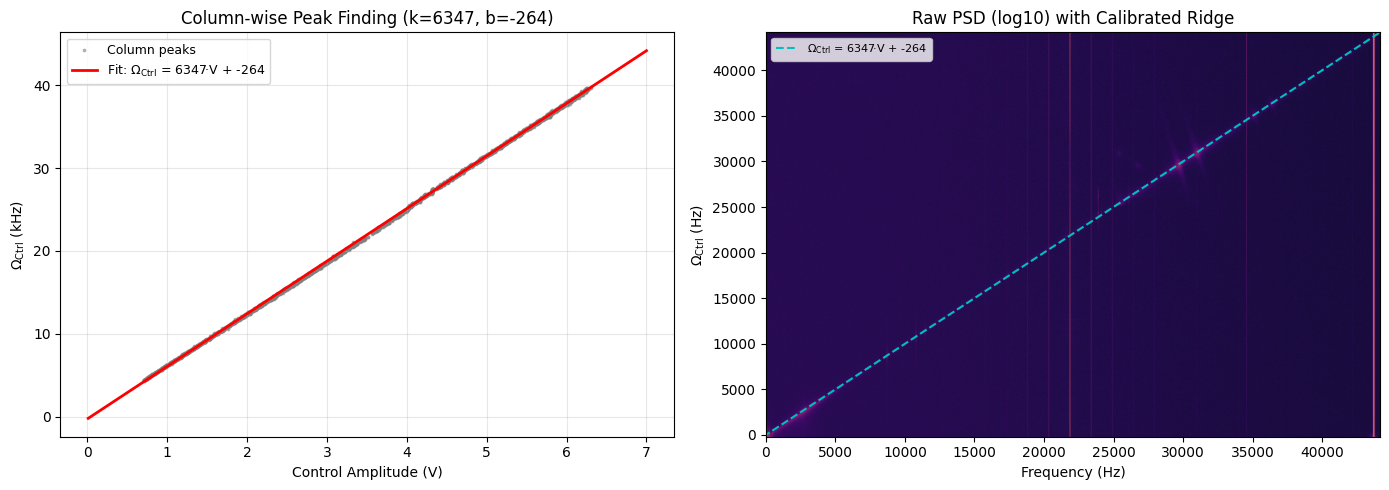

In [17]:
# ===== 幅频标定：逐列寻峰 =====
# 原理:
#   对固定频率 ω_j，沿幅度轴看 PSD → 在 V_peak 处有共振峰，其他 V 处 ≈ N_S1。
#   逐列 find_peaks 找最大 prominence 峰 → (f_j, V_peak_j)。
#   然后 k·V+b 拟合 + 迭代 2σ 离群拒绝。

# 如果已加载标定结果则跳过
from scipy.signal import find_peaks

OMEGA_CTRL_EST_K = 7000  # 有效控制频率经验斜率 (Hz/V)
PEAK_PROMINENCE_MIN = None  # 最小prominence阈值，None=自动用col.std的0.1倍

# ============ Step 0: 估计Ω_Ctrl频率范围 ============
f_lo = max(0, OMEGA_CTRL_EST_K * amplitudes_used[0] - 5000)
f_hi = OMEGA_CTRL_EST_K * amplitudes_used[-1] + 5000
freq_mask = (freq_axis >= f_lo) & (freq_axis <= f_hi)
freq_indices = np.where(freq_mask)[0]
print(f"搜索范围: f ∈ [{f_lo:.0f}, {f_hi:.0f}] Hz, {len(freq_indices)} 频率列")

# ============ Step 1: 逐列寻峰（含边界扩展） ============
def find_peaks_extended(col, ext_ratio=0.1):
    """对称扩展后寻峰，避免漏掉边界附近的真峰"""
    n = len(col)
    n_ext = int(n * ext_ratio)
    col_ext = np.concatenate([col[n_ext-1::-1], col, col[:-n_ext-1:-1]])
    peaks_ext, props = find_peaks(col_ext, prominence=0)
    peaks = peaks_ext - n_ext
    valid = (peaks >= 0) & (peaks < n)
    return peaks[valid], props["prominences"][valid]

peak_amps = np.full(len(freq_axis), np.nan)

for j in freq_indices:
    col = psd_matrix[:, j]
    if np.all(np.isnan(col)):
        continue

    peaks, prominences = find_peaks_extended(col)
    if len(peaks) == 0:
        continue

    # 自动prominence阈值
    thresh = PEAK_PROMINENCE_MIN if PEAK_PROMINENCE_MIN is not None else 0.1 * np.nanstd(col)
    valid_peak = prominences > thresh
    if not np.any(valid_peak):
        continue

    # 只在有效峰中选prominence最大的
    valid_idx = np.where(valid_peak)[0]
    best = valid_idx[np.argmax(prominences[valid_peak])]
    peak_amps[j] = amplitudes_used[peaks[best]]

# 有效点筛选: 峰不能太靠近幅度边界
valid_cal = ~np.isnan(peak_amps)
amp_lo = amplitudes_used[0] + 0.1 * (amplitudes_used[-1] - amplitudes_used[0])
amp_hi = amplitudes_used[-1] - 0.1 * (amplitudes_used[-1] - amplitudes_used[0])
valid_cal &= (peak_amps >= amp_lo) & (peak_amps <= amp_hi)

V_cal = peak_amps[valid_cal]
f_cal = freq_axis[valid_cal]
n_total = len(freq_indices)
print(f"逐列寻峰: {np.sum(valid_cal)}/{n_total} 有效峰 ({100*np.sum(valid_cal)/max(n_total,1):.1f}%)")

# ============ Step 2: k·V+b 拟合 + 迭代2σ离群拒绝 ============
if len(V_cal) > 5:
    for _ in range(5):
        k, b = np.polyfit(V_cal, f_cal, 1)
        resid = f_cal - (k * V_cal + b)
        resid_std = np.std(resid)
        inlier = np.abs(resid) <= 2 * resid_std
        if np.all(inlier) or np.sum(inlier) < 5:
            break
        V_cal, f_cal = V_cal[inlier], f_cal[inlier]
    k, b = np.polyfit(V_cal, f_cal, 1)
    print(f"  迭代2σ离群拒绝完成: 保留 {len(V_cal)} 点")
else:
    k, b = OMEGA_CTRL_EST_K, 0.0
    print("⚠️ 有效峰不足，使用经验估计")

omega_ctrl = k * amplitudes_used + b
print(f"\n幅频标定结果:")
print(f"  k = {k:.2f} Hz/V")
print(f"  b = {b:.2f} Hz")
print(f"  Ω_Ctrl = {k:.2f} · V + {b:.2f}")

# 保存
np.savez(results_dir / "calibration.npz",
            k=k, b=b, amplitudes=amplitudes_used, omega_ctrl=omega_ctrl,
            peak_amps=peak_amps, V_cal=V_cal, f_cal=f_cal)
print(f"标定结果已保存: {results_dir / 'calibration.npz'}")

# ---- 标定图（1×2：散点拟合 + PSD伪彩图纵轴为Ω_Ctrl） ----
fig_cal, axes_cal = plt.subplots(1, 2, figsize=(14, 5))

# 图 a: 散点 + 拟合
ax = axes_cal[0]
ax.scatter(V_cal, f_cal / 1000, s=3, alpha=0.5, color="gray", label="Column peaks")
ax.plot(amplitudes_used, omega_ctrl / 1000, "r-", linewidth=2,
        label=f"Fit: $\\Omega_{{\\mathrm{{Ctrl}}}}$ = {k:.0f}·V + {b:.0f}")
ax.set_xlabel("Control Amplitude (V)")
ax.set_ylabel("$\\Omega_{\\mathrm{Ctrl}}$ (kHz)")
ax.set_title(f"Column-wise Peak Finding (k={k:.0f}, b={b:.0f})")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 图 b: 原始 PSD log（纵轴映射为 Ω_Ctrl，x轴聚焦至脊线区域）
ax = axes_cal[1]
psd_log = np.log10(np.maximum(psd_matrix, 1e-20))
omega_min, omega_max = omega_ctrl[0], omega_ctrl[-1]
extent = [freq_axis[0], freq_axis[-1], omega_min, omega_max]
ax.imshow(psd_log, aspect="auto", origin="lower", extent=extent, cmap="inferno")
ax.plot([omega_min, omega_max], [omega_min, omega_max],
        "c--", linewidth=1.5, label=f"$\\Omega_{{\\mathrm{{Ctrl}}}}$ = {k:.0f}·V + {b:.0f}")
ax.set_xlim(0, omega_max)
ax.set_ylim(omega_min, omega_max)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("$\\Omega_{\\mathrm{Ctrl}}$ (Hz)")
ax.set_title("Raw PSD (log10) with Calibrated Ridge")
ax.legend(fontsize=8)

fig_cal.tight_layout()
fig_cal.savefig(results_dir / "calibration.png", dpi=150)
print(f"标定图已保存: {results_dir / 'calibration.png'}")

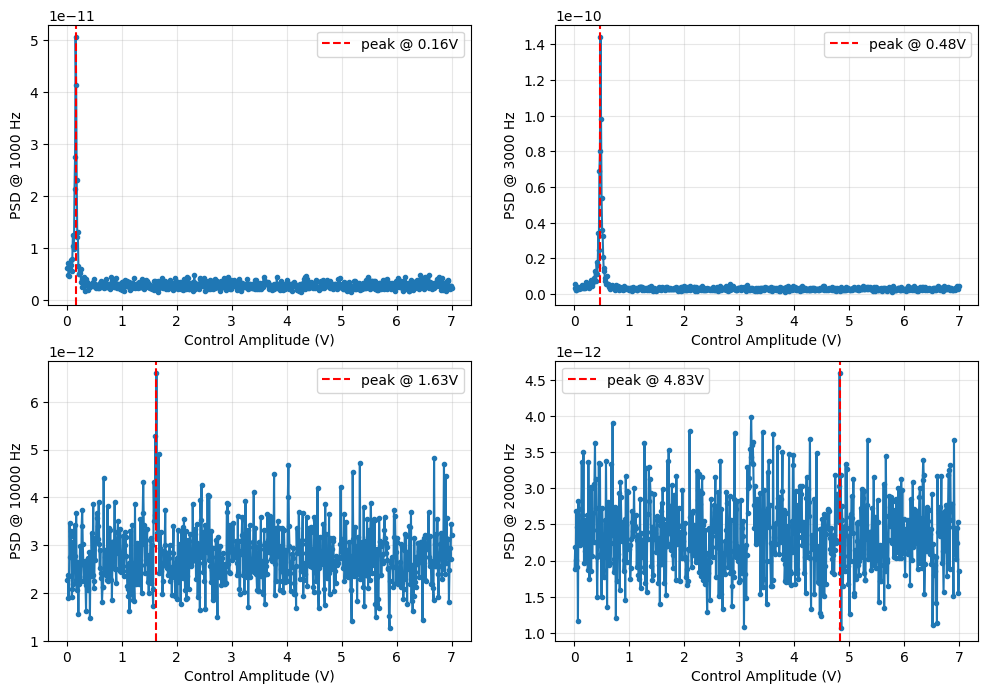

In [18]:
# 诊断：查看特定频率列沿幅度轴的 PSD 曲线
test_freqs = [1000, 3000, 10000,20000]  # Hz
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, f_idx in zip(axes.flatten(), [np.argmin(np.abs(freq_axis - f)) for f in test_freqs]):
    ax.plot(amplitudes_used, psd_matrix[:, f_idx], 'o-', ms=3)
    ax.axvline(amplitudes_used[np.argmax(psd_matrix[:, f_idx])], 
               color='r', ls='--', label=f'peak @ {amplitudes_used[np.argmax(psd_matrix[:, f_idx])]:.2f}V')
    ax.set_xlabel('Control Amplitude (V)')
    ax.set_ylabel(f'PSD @ {freq_axis[f_idx]:.0f} Hz')
    ax.legend()
    ax.grid(True, alpha=0.3)


In [23]:
# ===== 洛伦兹拟合提取噪声参数 =====
# 在每个频率点 ω 上，对控制强度 Ω_Ctrl 做洛伦兹拟合
#
# S_S1(Ω_Ctrl; ω) = D + A · (γ² + ω²) / ((γ² - ω² + (Ω_Ctrl + Δω)²)² + 4ω²γ²)
#
# 拟合参数: gamma (γ), Amp (A), D (N_S1), dw (Δω)

def lorentzian_vs_omega(omega_ctrl, gamma, Amp, D, dw, omega_fixed):
    """洛伦兹函数: PSD vs 控制强度，在固定频率 omega_fixed 上"""
    w = omega_fixed
    Om = omega_ctrl + dw
    return D + Amp * (gamma**2 + w**2) / (
        (gamma**2 - w**2 + Om**2)**2 + 4 * w**2 * gamma**2
    )

# ---- 逆向估计 Amp 初始值（来自 oldcode） ----
def estimate_amp_guess(psd_max, gamma_guess, omega_fixed):
    """
    从洛伦兹峰值的解析公式反向求解 Amp:
    在共振时 (OmegaCtrl ~ omega), 洛伦兹分母 ≈ (γ² - ω² + ω²)² = γ⁴, 分子 = γ² + ω²
    → 峰高 ≈ Amp × (γ² + ω²) / γ⁴
    → Amp ≈ 峰高 × γ⁴ / (γ² + ω²)
    """
    peak_height = psd_max
    denom = (gamma_guess**2 + omega_fixed**2)
    return peak_height * (gamma_guess**4 + 4 * gamma_guess**2 * omega_fixed**2) / denom

# ---- 配置拟合参数 ----
PEAK_MARGIN = 10000        # 脊线附近 ±10 kHz 内检测共振峰
GAMMA_GUESS = 300          # 初始线宽估计

# 构造 Ω_Ctrl 轴
omega_ctrl_axis = k * amplitudes_used + b

n_freq = len(freq_axis)
popt_list = np.full((n_freq, 4), np.nan)  # gamma, Amp, D, dw
perr_list = np.full((n_freq, 4), np.nan)
fit_mask = np.zeros(n_freq, dtype=bool)

print("洛伦兹拟合中...")
for j in range(n_freq):
    psd_slice = psd_matrix[:, j]
    if np.all(np.isnan(psd_slice)):
        continue

    SwFreq = freq_axis[j]

    # ---- 只在脊线附近 [SwFreq-10k, SwFreq+10k] 内检测峰 ----
    peak_range = [SwFreq - PEAK_MARGIN, SwFreq + PEAK_MARGIN]
    peak_idx_lo = np.searchsorted(omega_ctrl_axis, peak_range[0])
    peak_idx_hi = np.searchsorted(omega_ctrl_axis, peak_range[1])
    if peak_idx_hi <= peak_idx_lo:
        continue

    local_slice = psd_slice[peak_idx_lo:peak_idx_hi]
    median_val = np.nanmedian(psd_slice)
    std_val = np.nanstd(psd_slice)
    max_val = np.nanmax(local_slice)

    # ---- 预筛选：max - median > 2σ 时才尝试拟合 ----
    if max_val - median_val <= 2 * std_val:
        continue

    valid = ~np.isnan(psd_slice) & ~np.isnan(omega_ctrl_axis)
    if np.sum(valid) < 10:
        continue

    x_data = omega_ctrl_axis[valid]
    y_data = psd_slice[valid]

    # ---- 初始值估计 ----
    gamma_guess = GAMMA_GUESS
    baseline_guess = median_val
    Amp_guess = estimate_amp_guess(max_val - median_val, gamma_guess, SwFreq)
    dw_guess = 0.0

    try:
        popt, pcov = curve_fit(
            lambda x, g, A, D, dw: lorentzian_vs_omega(x, g, A, D, dw, SwFreq),
            x_data, y_data,
            p0=[gamma_guess, Amp_guess, baseline_guess, dw_guess],
            maxfev=5000,
        )
        # Amp 和 gamma 取绝对值
        popt_list[j, :] = [np.abs(popt[0]), np.abs(popt[1]), popt[2], popt[3]]
        perr_list[j, :] = np.sqrt(np.diag(pcov))
        fit_mask[j] = True
    except (RuntimeError, ValueError) as e:
        pass  # 拟合失败，保留 NaN

fitted_count = np.sum(fit_mask)
print(f"拟合完成: {fitted_count}/{n_freq} 频率点拟合成功 ({100*fitted_count/n_freq:.1f}%)")

# [经验] 失败点用线性插值填充（仅在脊线附近的合理频率范围内）
FIT_OMEGA_MARGIN = 0.5  # 脊线外扩 50%
f_lo_fit = max(0, omega_ctrl[0] * (1 - FIT_OMEGA_MARGIN))
f_hi_fit = omega_ctrl[-1] * (1 + FIT_OMEGA_MARGIN)

if fitted_count > 0 and fitted_count < n_freq:
    from scipy.interpolate import interp1d

    for param_idx in range(4):
        near_ridge = (freq_axis >= f_lo_fit) & (freq_axis <= f_hi_fit)
        mask_near = fit_mask & near_ridge
        if np.sum(mask_near) > 2:
            interp_func = interp1d(
                np.where(mask_near)[0], popt_list[mask_near, param_idx],
                kind="linear", fill_value="extrapolate",
            )
            fill_idx = np.where(~fit_mask & near_ridge)[0]
            for idx in fill_idx:
                popt_list[idx, param_idx] = float(interp_func(idx))

    print("脊线附近失败点已用线性插值填充，远离脊线的保持 NaN")

# 提取噪声谱
S_beta = popt_list[:, 1].copy()  # Amp → 可控噪声
N_S1   = popt_list[:, 2].copy()  # D → 不可控噪声

# 保存拟合结果
np.savez(
    results_dir / "popt_fit.npz",
    popt=popt_list,
    perr=perr_list,
    fit_mask=fit_mask,
    freq_axis=freq_axis,
    param_names=["gamma", "Amp", "D", "dw"],
)

# [经验] 保存 noise_spectra.npz 供最优控制设计 Notebook 加载
np.savez(
    results_dir / "noise_spectra.npz",
    S_beta=S_beta,
    N_S1=N_S1,
    freq_axis=freq_axis,
    amplitudes=amplitudes_used,
    omega_ctrl=omega_ctrl,
)
print(f"\n噪声谱已保存: {results_dir / 'noise_spectra.npz'}")
print(f"  S_beta (可控噪声): {S_beta.shape}, 有效: {np.sum(~np.isnan(S_beta))} 点")
print(f"  N_S1 (不可控噪声): {N_S1.shape}, 有效: {np.sum(~np.isnan(N_S1))} 点")
print(f"  freq_axis: {freq_axis[0]:.0f} - {freq_axis[-1]:.0f} Hz")

洛伦兹拟合中...


C:\Users\LiuHC\AppData\Local\Temp\ipykernel_25992\403632753.py:78: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(


拟合完成: 4958/5001 频率点拟合成功 (99.1%)
脊线附近失败点已用线性插值填充，远离脊线的保持 NaN

噪声谱已保存: d:\Code\exp_agent\data\Noise_Spectrum_XY_Ctrl\0520_0937_noise\results\noise_spectra.npz
  S_beta (可控噪声): (5001,), 有效: 5001 点
  N_S1 (不可控噪声): (5001,), 有效: 5001 点
  freq_axis: 0 - 50000 Hz


<a id='plot'></a>
## 6. 结果可视化

绘制 PSD 二维伪彩图、典型幅度 PSD 及其拟合曲线、提取的可控/不可控噪声谱。

PSD log10 颜色范围: [-11.93, -11.43] (P5–P95)
PSD 伪彩图已保存
提取的噪声谱已保存


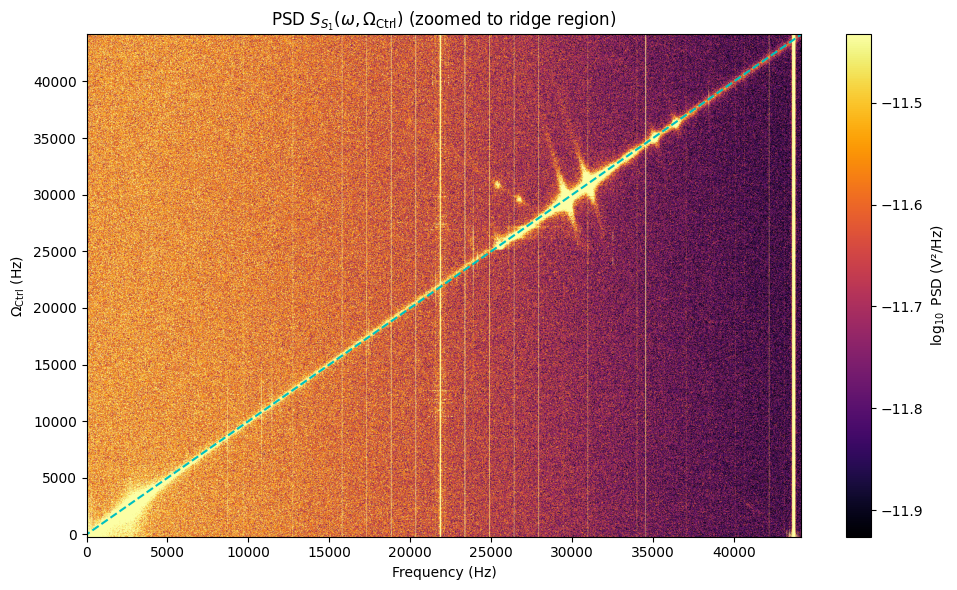

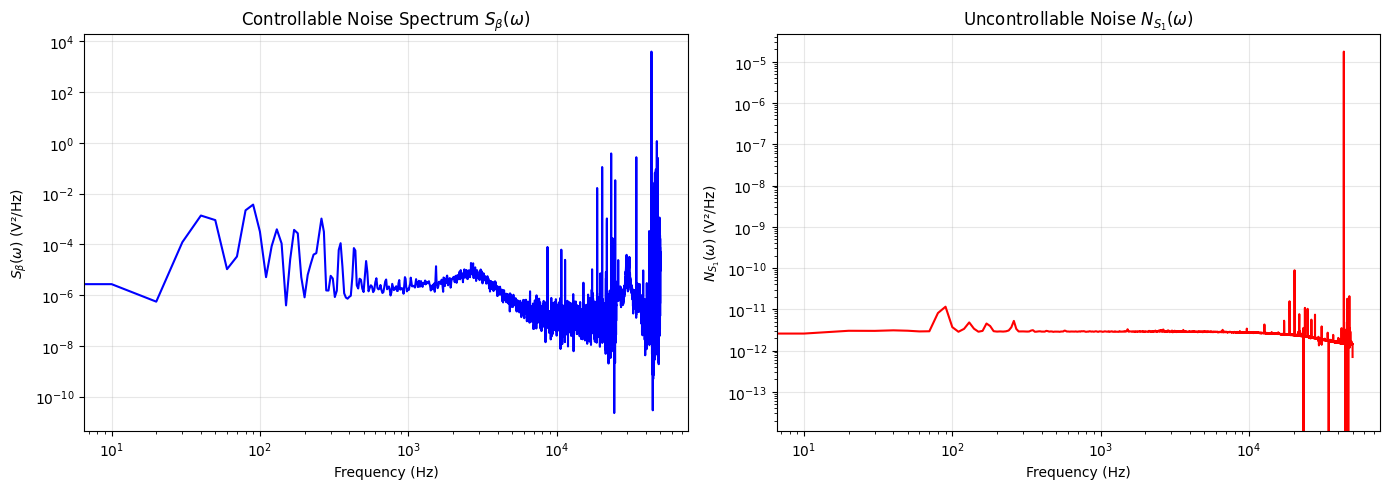


所有图表已保存至: d:\Code\exp_agent\data\Noise_Spectrum_XY_Ctrl\0520_0937_noise\results


In [22]:
# ===== 绘制结果图 =====

# ---- 图 1: PSD 二维伪彩图（纵轴映射为 Ω_Ctrl，聚焦脊线区域） ----
fig1, ax1 = plt.subplots(figsize=(10, 6))
psd_log = np.log10(np.maximum(psd_matrix, 1e-20))
# 百分位截断：裁剪颜色范围，排除极大噪声峰干扰，凸显脊背
vmin_pct, vmax_pct = 5, 95
vmin = np.nanpercentile(psd_log, vmin_pct)
vmax = np.nanpercentile(psd_log, vmax_pct)
print(f"PSD log10 颜色范围: [{vmin:.2f}, {vmax:.2f}] (P{vmin_pct}–P{vmax_pct})")
# 纵轴从幅度映射为 Ω_Ctrl
omega_min_1, omega_max_1 = omega_ctrl[0], omega_ctrl[-1]
extent = [freq_axis[0], freq_axis[-1], omega_min_1, omega_max_1]
im = ax1.imshow(psd_log, aspect="auto", origin="lower",
                extent=extent, cmap="inferno",
                vmin=vmin, vmax=vmax)
ax1.set_xlim(0, omega_max_1)
# 叠加标定脊线（对角线上 Ω_Ctrl = ω）
ax1.plot([omega_min_1, omega_max_1], [omega_min_1, omega_max_1],
         "c--", linewidth=1.5, label=f"$\\Omega_{{\\mathrm{{Ctrl}}}}$ = {k:.0f}·V + {b:.0f}")
ax1.set_xlabel("Frequency (Hz)")
ax1.set_ylabel("$\\Omega_{\\mathrm{Ctrl}}$ (Hz)")
ax1.set_title("PSD $S_{S_1}(\\omega, \\Omega_\\mathrm{Ctrl})$ (zoomed to ridge region)")
cb1 = fig1.colorbar(im, ax=ax1, label="$\\log_{10}$ PSD (V²/Hz)")
fig1.tight_layout()
fig1.savefig(results_dir / "noise_spectrum_2d.png", dpi=150)
print(f"PSD 伪彩图已保存")

# ---- 图 2: 提取的噪声谱 ----
fig2, (ax2a, ax2b) = plt.subplots(1, 2, figsize=(14, 5))

ax2a.loglog(freq_axis, S_beta, "b-", linewidth=1.5)
ax2a.set_xlabel("Frequency (Hz)")
ax2a.set_ylabel("$S_\\beta(\\omega)$ (V²/Hz)")
ax2a.set_title("Controllable Noise Spectrum $S_\\beta(\\omega)$")
ax2a.grid(True, alpha=0.3)

ax2b.loglog(freq_axis, N_S1, "r-", linewidth=1.5)
ax2b.set_xlabel("Frequency (Hz)")
ax2b.set_ylabel("$N_{S_1}(\\omega)$ (V²/Hz)")
ax2b.set_title("Uncontrollable Noise $N_{S_1}(\\omega)$")
ax2b.grid(True, alpha=0.3)

fig2.tight_layout()
fig2.savefig(results_dir / "noise_spectra_extracted.png", dpi=150)
print(f"提取的噪声谱已保存")

plt.show()
print(f"\n所有图表已保存至: {results_dir}")

<a id='cleanup'></a>
## 7. 安全关闭

按顺序关闭各设备输出，断开仪器连接。

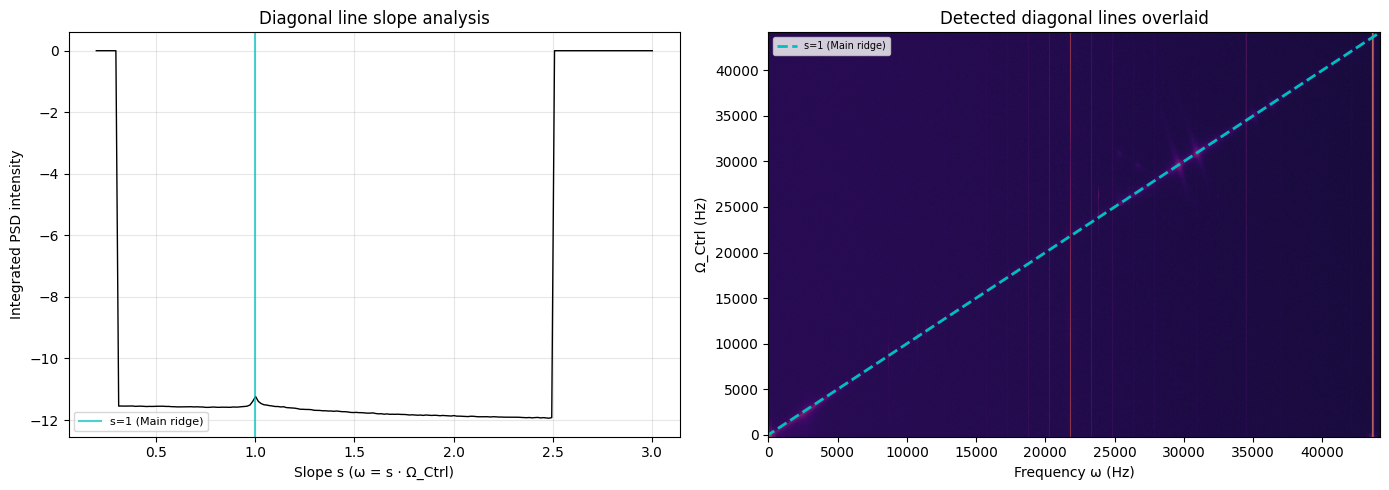


斜向亮线分析结果
主脊线: s = 1.00 (ω = Ω_Ctrl, 洛伦兹共振)

验证建议:
  1. 用频谱仪测 DG4000 输出，确认谐波含量
  2. 在固定幅度下做 PSD 线图，看峰的频率位置
  3. 改变 Pump 调制占空比，观察斜线是否变化


In [ ]:
# ===== 诊断：分析 PSD 图中斜线的斜率（正负斜率均检测）=====
# 对 PSD 矩阵沿各种方向做线积分（Radon 变换思想），
# 同时检测正斜率（ω ∝ Ω_Ctrl）和负斜率（ω + k·Ω_Ctrl = const）特征。

psd_for_analysis = np.log10(np.maximum(psd_matrix, 1e-20))
omega_max_diag = omega_ctrl[-1]

# ---- 方法: 在 (Ω_Ctrl, ω) 平面上沿直线做线积分 ----
# 参数化: ω = s · Ω_Ctrl + offset
# 正斜率 s > 0: 过原点的射线族
# 负斜率 s < 0: ω = -s · Ω_Ctrl + offset，offset 为 ω 轴截距
# 
# 对固定截距 offset，扫描斜率 s，找积分最强的 s 值

# 先检测负斜率特征：固定 offset，扫描 s
# 负斜率线的特征：Ω_Ctrl 增大时 ω 减小 → 在更低的 PSD 频率上响应更强

# ---- 1. 沿 ω = -Ω_Ctrl + offset 方向积分（斜率 -1 附近）----
# 对每个 offset (ω 轴截距)，沿 ω = -Ω_Ctrl + offset 收集数据
offset_candidates = np.linspace(freq_axis[0], freq_axis[-1], 300)
score_neg1 = np.zeros_like(offset_candidates)

for idx_off, offset in enumerate(offset_candidates):
    w_target = -omega_ctrl + offset
    mask = (w_target >= freq_axis[0]) & (w_target <= freq_axis[-1])
    if np.sum(mask) < 10:
        continue
    score = 0
    for i in np.where(mask)[0]:
        j = np.argmin(np.abs(freq_axis - w_target[i]))
        score += psd_for_analysis[i, j]
    score_neg1[idx_off] = score / np.sum(mask)

# ---- 2. 通用负斜率检测：ω = s_neg · Ω_Ctrl + offset，s_neg < 0 ----
# 对每个斜率 s_neg 和 offset 的二维扫描
# 简化：扫描 s_neg 从 -0.2 到 -3.0（步长 0.1），对每个 s_neg 找最优 offset

s_neg_candidates = -np.linspace(0.2, 3.0, 30)
best_scores_neg = np.zeros_like(s_neg_candidates)

for idx_s, s_neg in enumerate(s_neg_candidates):
    offset_scores = np.zeros_like(offset_candidates)
    for idx_off, offset in enumerate(offset_candidates):
        w_target = s_neg * omega_ctrl + offset
        mask = (w_target >= freq_axis[0]) & (w_target <= freq_axis[-1])
        if np.sum(mask) < 10:
            offset_scores[idx_off] = -np.inf
            continue
        score = 0
        for i in np.where(mask)[0]:
            j = np.argmin(np.abs(freq_axis - w_target[i]))
            score += psd_for_analysis[i, j]
        offset_scores[idx_off] = score / np.sum(mask)
    best_scores_neg[idx_s] = np.max(offset_scores)

# ---- 3. 正斜率检测（已有的，补充） ----
slope_candidates = np.linspace(0.2, 3.0, 200)
integration_score = np.zeros_like(slope_candidates)
ridge_lower = omega_ctrl * 0.3
ridge_upper = omega_ctrl * 2.5

for idx_s, s in enumerate(slope_candidates):
    w_target = s * omega_ctrl
    mask = (w_target >= ridge_lower) & (w_target <= ridge_upper)
    if np.sum(mask) < 10:
        continue
    score = 0
    for i in np.where(mask)[0]:
        j = np.argmin(np.abs(freq_axis - w_target[i]))
        score += psd_for_analysis[i, j]
    integration_score[idx_s] = score / np.sum(mask)

# ---- 汇总并排序检测到的特征 ----
from scipy.signal import find_peaks

# 正斜率峰值
peaks_pos, props_pos = find_peaks(integration_score, prominence=0.5, height=0)
# 负斜率峰值
peaks_neg, props_neg = find_peaks(best_scores_neg, prominence=0.5, height=0)

# 找出负斜率中峰值对应的具体 offset
detected_features = []

# 添加正斜率特征
for p in peaks_pos:
    s = slope_candidates[p]
    h = integration_score[p]
    detected_features.append({"type": "positive", "slope": s, "height": h, "desc": f"ω = {s:.2f}·Ω_Ctrl"})

# 添加负斜率特征
for p in peaks_neg:
    s_neg = s_neg_candidates[p]
    h = best_scores_neg[p]
    detected_features.append({"type": "negative", "slope": s_neg, "height": h, "desc": f"ω = {s_neg:.2f}·Ω_Ctrl + offset"})

# 按强度排序
detected_features.sort(key=lambda x: x["height"], reverse=True)

# ---- 绘制诊断图 ----
fig_diag, axes_diag = plt.subplots(2, 2, figsize=(14, 10))

# (a) 正斜率积分
ax0 = axes_diag[0, 0]
ax0.plot(slope_candidates, integration_score, 'k-', linewidth=1)
for feat in detected_features[:5]:
    if feat["type"] != "positive": continue
    ax0.axvline(feat["slope"], color='r', linestyle='--', alpha=0.5)
    ax0.text(feat["slope"], feat["height"]*1.1, f's={feat["slope"]:.2f}', fontsize=9, ha='center')
ax0.axvline(1.0, color='c', linestyle='-', alpha=0.7, label='s=1 (Main ridge)')
ax0.set_xlabel("Slope s (ω = s · Ω_Ctrl)")
ax0.set_ylabel("Integrated intensity")
ax0.set_title("(a) Positive slope analysis")
ax0.legend(fontsize=8)
ax0.grid(True, alpha=0.3)

# (b) 负斜率积分
ax1 = axes_diag[0, 1]
ax1.plot(s_neg_candidates, best_scores_neg, 'k-', linewidth=1)
for feat in detected_features[:5]:
    if feat["type"] != "negative": continue
    ax1.axvline(feat["slope"], color='r', linestyle='--', alpha=0.5)
    ax1.text(feat["slope"], feat["height"]*1.1, f's={feat["slope"]:.2f}', fontsize=9, ha='center')
ax1.set_xlabel("Slope s_neg (ω = s_neg·Ω_Ctrl + offset)")
ax1.set_ylabel("Best offset-integrated intensity")
ax1.set_title("(b) Negative slope analysis")
ax1.grid(True, alpha=0.3)

# (c) PSD 原图 + 标注检测到的特征
ax2 = axes_diag[1, 0]
extent_d = [freq_axis[0], freq_axis[-1], omega_ctrl[0], omega_ctrl[-1]]
ax2.imshow(psd_for_analysis, aspect="auto", origin="lower",
           extent=extent_d, cmap="inferno")
ax2.set_xlim(0, omega_max_diag)

# 标注主脊线
ax2.plot([omega_ctrl[0], omega_ctrl[-1]], [omega_ctrl[0], omega_ctrl[-1]],
         "c-", linewidth=2, alpha=0.8, label="s=+1 (Main ridge)")

# 标注检测到的正斜率特征
colors_line = ['r--', 'y--', 'g--', 'm--', 'w--']
for idx_feat, feat in enumerate(detected_features[:8]):
    if feat["type"] == "positive" and abs(feat["slope"] - 1.0) > 0.05:
        s = feat["slope"]
        ax2.plot([omega_ctrl[0], omega_ctrl[-1]],
                 [omega_ctrl[0]*s, omega_ctrl[-1]*s],
                 colors_line[idx_feat % len(colors_line)],
                 linewidth=1.2, alpha=0.6,
                 label=f's=+{s:.2f}')                 
ax2.set_xlabel("Frequency ω (Hz)")
ax2.set_ylabel("Ω_Ctrl (Hz)")
ax2.set_title("(c) PSD with detected features")
ax2.legend(fontsize=6, loc='upper left')

# (d) 负斜率特征标注（ω = s·Ω_Ctrl + offset，选取最优 offset）
ax3 = axes_diag[1, 1]
ax3.imshow(psd_for_analysis, aspect="auto", origin="lower",
           extent=extent_d, cmap="inferno")
ax3.set_xlim(0, omega_max_diag)
ax3.plot([omega_ctrl[0], omega_ctrl[-1]], [omega_ctrl[0], omega_ctrl[-1]],
         "c-", linewidth=2, alpha=0.8, label="s=+1 (Main ridge)")

# 标注负斜率特征（选最优 offset 画线）
for idx_feat, feat in enumerate(detected_features[:8]):
    if feat["type"] != "negative": continue
    s_neg = feat["slope"]
    # 重新找这个斜率对应的最优 offset
    best_off = 0; best_sc = -np.inf
    for offset in offset_candidates:
        w_target = s_neg * omega_ctrl + offset
        mask = (w_target >= freq_axis[0]) & (w_target <= freq_axis[-1])
        if np.sum(mask) < 10: continue
        sc = 0
        for i in np.where(mask)[0]:
            j = np.argmin(np.abs(freq_axis - w_target[i]))
            sc += psd_for_analysis[i, j]
        sc /= np.sum(mask)
        if sc > best_sc:
            best_sc = sc; best_off = offset
    
    # 画该负斜率线
    w_line = s_neg * omega_ctrl + best_off
    mask_line = (w_line >= freq_axis[0]) & (w_line <= freq_axis[-1])
    if np.sum(mask_line) > 10:
        ax3.plot(omega_ctrl[mask_line], w_line[mask_line],
                 colors_line[idx_feat % len(colors_line)],
                 linewidth=1.5, alpha=0.7,
                 label=f's={s_neg:.2f}, off={best_off:.0f}Hz')

ax3.set_xlabel("Frequency ω (Hz)")
ax3.set_ylabel("Ω_Ctrl (Hz)")
ax3.set_title("(d) Negative-slope features on PSD")
ax3.legend(fontsize=6, loc='upper left')

fig_diag.tight_layout()
fig_diag.savefig(results_dir / "diagonal_analysis.png", dpi=150)
plt.show()

# ---- 打印结果解读 ----
print("\n" + "=" * 65)
print("斜线检测结果（按强度排序）")
print("=" * 65)
n_printed = 0
for feat in detected_features[:12]:
    if feat["type"] == "positive" and abs(feat["slope"] - 1.0) < 0.05:
        print(f"  ★ 正斜率 s = {feat['slope']:.2f}  ← 主脊线 (洛伦兹共振)")
        continue
    n_printed += 1
    if feat["type"] == "positive":
        print(f"  [{n_printed}] 正斜率 s = {feat['slope']:.2f}", end="")
        s = feat["slope"]
        if abs(s - 2.0) < 0.15: print(" ← 可能: 二次谐波 (2Ω_Ctrl)")
        elif abs(s - 3.0) < 0.2: print(" ← 可能: 三次谐波 (3Ω_Ctrl)")
        elif abs(s - 0.5) < 0.08: print(" ← 可能: 次谐波 (Ω_Ctrl/2)")
        elif abs(s - 1.5) < 0.1: print(" ← 可能: 3/2 谐波")
        else: print()
    else:
        print(f"  [{n_printed}] 负斜率 s = {feat['slope']:.2f}", end="")
        s = abs(feat["slope"])
        if abs(s - 1.0) < 0.15: print(" ← 可能: ω+Ω_Ctrl=const (差频混合)")
        elif abs(s - 2.0) < 0.15: print(" ← 可能: ω+2Ω_Ctrl=const")
        elif abs(s - 0.5) < 0.08: print(" ← 可能: 2ω+Ω_Ctrl=const")
        else: print(f" (offset ≈ 待查)")

print("\n验证建议:")
print("  1. 在 PSD 图上取斜线上几个点，验算 ω 和 Ω_Ctrl 的关系")
print("  2. 关掉 XY 控制场（Ω_Ctrl=0），看特征是否消失 → 判断是否与控制场相关")
print("  3. 改变 Pump 调制频率（90kHz），看特征频率偏移 → 判断是否与 Pump 相关")

In [ ]:
# ===== 安全断开设备 =====
print("安全断开设备...")

# 1. 关闭 X/Y 补偿输出
dev = devices.get("dg_comp")
if dev:
    dev.set_output(False, channel=1)
    dev.set_output(False, channel=2)
    print("  X/Y 补偿: 输出 OFF")
    dev.set_sync_state(False, channel=1)
    dev.set_sync_state(False, channel=2)
    dev.set_burst_state(False, channel=1)
    dev.set_burst_state(False, channel=2)

# 2. 关闭 Z 磁场输出
dev = devices.get("dg_sweep")
if dev:
    dev.set_output(False, channel=1)
    dev.set_output(False, channel=2)
    print("  Z 磁场: 输出 OFF")

# 3. 恢复温度开关
dev = devices.get("dg_temp")
if dev:
    dev.set_output(True, channel=2)
    print("  温度开关: ON (确保温控恢复)")

# 4. 关闭 Pump 调制及 SYNC
dev = devices.get("dg_mod")
if dev:
    dev.set_sync_state(False, channel=2)
    dev.set_output(False, channel=1)
    dev.set_output(False, channel=2)
    print("  Pump 调制: SYNC OFF, 输出 OFF")

# 5. 关闭 GS200 主磁场
dev = devices.get("gs200")
if dev:
    dev.set_output(False)
    print("  主磁场 GS200: 输出 OFF")

# 6. 关闭光功率
dev = devices.get("dg_laser")
if dev:
    dev.set_output(False, channel=1)
    dev.set_output(False, channel=2)
    print("  光功率: 输出 OFF")

# 7. 关闭 HF2（解调器 disable）
dev = devices.get("hf2")
if dev:
    demod.set_demod_enable(dev, 0, False)
    print("  HF2: 解调器 0 DISABLE")

# 8. 断开所有连接
for name, dev in devices.items():
    try:
        if hasattr(dev, "disconnect"):
            dev.disconnect()
            print(f"  {name}: 已断开")
    except Exception as e:
        print(f"  {name} 断开失败: {e}")

print("\n✅ 所有设备已安全断开")